# ECE 8803-AI4 — Lab: An Agentic AI Process Engineer

**Goal:** build an LLM agent that tunes a plasma etch recipe by *actually running a process
simulator*, not by talking about one. The agent proposes a recipe, the digital twin returns a
profile, the agent reads the metrology and iterates — a closed loop.

**The physical problem.** SF₆/O₂ plasma etch of a masked Si trench. The classic tension:
SF₆ radicals etch isotropically (fast, but they bow the sidewall and undercut the mask),
O₂ passivates the sidewall (straight profile, but slower etch). Ion energy and angular
spread set the directionality. There is no closed-form recipe — you search.

**Stack**
- **Digital twin:** [ViennaPS](https://github.com/ViennaTools/ViennaPS) — open-source level-set
  topography simulator with Monte Carlo ray tracing for feature-scale flux. `pip`-installable.
- **Agent:** Claude via the Anthropic Messages API with tool use. Any tool-calling LLM works;
  see the SemiKong note at the end for a fully open-source swap.

**What students should take away:** the interesting engineering is *not* the prompt. It's the
tool interface, the metrology extraction, the loss function, and the honest baseline.

Runtime: ~2–5 s per simulation, ~5 min end to end on a Colab CPU runtime. No GPU needed.

## 0. Setup

In [1]:
!pip install -q ViennaPS anthropic

In [2]:
import numpy as np, matplotlib.pyplot as plt, json, time, os, sys
import viennaps as vps, viennals as vls

vps.setDimension(2)
vps.Logger.setLogLevel(vps.LogLevel.ERROR)
vps.Length.setUnit("um")
vps.Time.setUnit("min")
# NOTE: ViennaPS 4.6.2 segfaults with >1 thread on macOS arm64 (Apple Silicon).
# Single-threaded is safe everywhere. On Linux/Windows you can raise this.
N_THREADS = 1 if sys.platform == "darwin" else (os.cpu_count() or 2)
vps.setNumThreads(N_THREADS)
print("ViennaPS", vps.version, "|", N_THREADS, "thread(s)")

ViennaPS 4.6.2 | 1 thread(s)


objc[10605]: Class vtkCocoaFullScreenWindow is implemented in both /Users/akhan40/miniconda3/envs/ai4/lib/python3.11/site-packages/viennals/_core.cpython-311-darwin.so (0x10cbe59d0) and /Users/akhan40/miniconda3/envs/ai4/lib/python3.11/site-packages/viennaps/_core.cpython-311-darwin.so (0x11feedae0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[10605]: Class vtkCocoaServer is implemented in both /Users/akhan40/miniconda3/envs/ai4/lib/python3.11/site-packages/viennals/_core.cpython-311-darwin.so (0x10cbe59f8) and /Users/akhan40/miniconda3/envs/ai4/lib/python3.11/site-packages/viennaps/_core.cpython-311-darwin.so (0x11feedb08). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[10605]: Class vtkCocoaGLView is implemented in both /Users/akhan40/miniconda3/envs/ai4/lib/python3.11/site-packages/viennals/_core.cpython-311-darwin.so (0x10cbe5a48) and 

## 1. The digital twin

A 2D trench, 400 nm wide, with a 400 nm hard mask, etched in SF₆/O₂. `ordered_profile` walks
the level-set surface mesh into a connected polyline so we can do metrology on it.

Grid and ray count are deliberately coarse — this is an *optimization loop*, not a publication
figure. Tighten `grid` and `rays` once your loop works.

In [3]:
TRENCH_W, MASK_H, XEXT = 0.4, 0.4, 1.0   # um

def ordered_profile(ls):
    # Level set -> ordered (N,2) polyline of the surface.
    mesh = vls.Mesh()
    vls.ToSurfaceMesh(ls, mesh).apply()
    nodes = np.array(mesh.getNodes())[:, :2]
    lines = np.array(mesh.getLines())
    nxt = {a: b for a, b in lines}
    targets = set(nxt.values())
    start = next((a for a in nxt if a not in targets), lines[0][0])
    order, cur, seen = [], start, set()
    while cur is not None and cur not in seen:
        seen.add(cur); order.append(cur); cur = nxt.get(cur)
    return nodes[order]

def etch(ion_flux=12.0, etchant_flux=1.8e3, oxygen_flux=1.0e2,
         mean_ion_energy=100.0, ion_exponent=200.0, duration=1.0,
         grid=0.06, rays=250):
    # Run one SF6/O2 trench etch. Returns the surface profile.
    d = vps.Domain(gridDelta=grid, xExtent=XEXT,
                   boundary=vps.BoundaryType.REFLECTIVE_BOUNDARY)
    vps.MakeTrench(d, trenchWidth=TRENCH_W, trenchDepth=0.0, maskHeight=MASK_H).apply()
    model = vps.SF6O2Etching(ionFlux=ion_flux, etchantFlux=etchant_flux,
                             oxygenFlux=oxygen_flux, meanIonEnergy=mean_ion_energy,
                             sigmaIonEnergy=10.0, ionExponent=ion_exponent)
    p = vps.Process(d, model, duration)
    rp = vps.RayTracingParameters(); rp.raysPerPoint = rays
    p.setParameters(rp)
    p.apply()
    return ordered_profile(d.getLevelSets()[-1])

### 1a. Virtual metrology

Four numbers a real process engineer would pull off a cross-section SEM:

| metric | definition |
|---|---|
| `depth` | etch front below the original Si surface (µm) |
| `taper_deg` | sidewall angle from 20% to 80% depth; **negative = bowed/retrograde** |
| `bow` | widest lateral excursion past the mask edge (µm) |
| `cd_top` | critical dimension just under the mask — mask undercut shows up here |

In [4]:
def metrics(prof):
    x, y = prof[:, 0], prof[:, 1]
    depth = float(-y.min())
    side = prof[(y < -0.02) & (x > 0)]          # right sidewall, below Si surface
    if len(side) < 3 or depth < 0.05:
        return dict(depth=depth, taper_deg=float("nan"),
                    bow=float("nan"), cd_top=float("nan"))
    def half_width(frac):
        i = np.argmin(np.abs(side[:, 1] + frac * depth))
        return float(side[i, 0])
    x20, x80 = half_width(0.2), half_width(0.8)
    return dict(
        depth      = round(depth, 4),
        taper_deg  = round(float(np.degrees(np.arctan2(x20 - x80, 0.6 * depth))), 3),
        bow        = round(float(side[:, 0].max() - TRENCH_W / 2), 4),
        cd_top     = round(2 * half_width(0.05), 4),
    )

def plot_profiles(runs, title=""):
    fig, ax = plt.subplots(figsize=(6, 5))
    for label, prof in runs:
        ax.plot(prof[:, 0], prof[:, 1], lw=1.8, label=label)
    ax.axhline(0, color="k", lw=0.6, ls=":")
    ax.axhline(-TARGET["depth"], color="crimson", lw=1.0, ls="--", label="target depth")
    ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
    ax.set_title(title); ax.set_aspect("equal"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

### 1b. Sanity check — the physics you expect

2.2 s for 2 runs
low  O2: {'depth': 1.534, 'taper_deg': -1.584, 'bow': 0.1432, 'cd_top': 0.4809}
high O2: {'depth': 1.3237, 'taper_deg': -0.368, 'bow': 0.0275, 'cd_top': 0.4028}


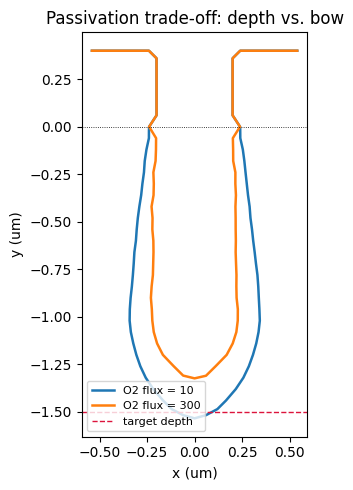

In [5]:
TARGET = dict(depth=1.50, depth_tol=0.05, bow_max=0.020, taper_max=1.0)

t0 = time.time()
lowO2  = etch(oxygen_flux=10.0,  duration=0.6)
highO2 = etch(oxygen_flux=300.0, duration=0.6)
print(f"{time.time()-t0:.1f} s for 2 runs")
print("low  O2:", metrics(lowO2))
print("high O2:", metrics(highO2))
plot_profiles([("O2 flux = 10", lowO2), ("O2 flux = 300", highO2)],
              "Passivation trade-off: depth vs. bow")

Low O₂ etches deeper but bows badly and undercuts the mask. High O₂ gives a near-vertical
sidewall and loses depth. **That trade-off is the whole optimization problem** — and it's why a
one-shot LLM answer is worthless here. The agent has to measure.

## 2. The spec and the loss

Every term is normalized so that **≤ 1.0 means in-spec**. `loss` is what we report; `passed`
is the actual acceptance criterion.

In [6]:
BOUNDS = {
    "ion_flux":        (1.0, 50.0),
    "etchant_flux":    (100.0, 5000.0),
    "oxygen_flux":     (1.0, 1000.0),
    "mean_ion_energy": (50.0, 300.0),
    "ion_exponent":    (50.0, 1000.0),
    "duration":        (0.2, 1.5),
}

def score(m):
    d = abs(m["depth"] - TARGET["depth"]) / TARGET["depth_tol"]
    b = max(0.0, m["bow"] - TARGET["bow_max"]) / TARGET["bow_max"]
    t = max(0.0, abs(m["taper_deg"]) - TARGET["taper_max"]) / TARGET["taper_max"]
    return dict(loss=round(float(d + b + t), 3),
                depth_err=round(float(d), 2), bow_pen=round(float(b), 2),
                taper_pen=round(float(t), 2),
                passed=bool(d <= 1.0 and b == 0.0 and t == 0.0))

_cache = {}
HISTORY = []   # every simulation ever run, by any method

def run_recipe(tag="", **kw):
    kw = {k: float(np.clip(v, *BOUNDS[k])) for k, v in kw.items()}
    key = tuple(sorted(kw.items()))
    if key not in _cache:
        prof = etch(**kw)
        _cache[key] = (prof, metrics(prof))
    prof, m = _cache[key]
    s = score(m)
    HISTORY.append(dict(tag=tag, params=kw, **m, **s))
    return prof, {**m, **s}

print(json.dumps(run_recipe(tag="seed", duration=0.7, oxygen_flux=100.0)[1], indent=2))

{
  "depth": 1.7441,
  "taper_deg": -2.357,
  "bow": 0.0847,
  "cd_top": 0.4187,
  "loss": 9.474,
  "depth_err": 4.88,
  "bow_pen": 3.23,
  "taper_pen": 1.36,
  "passed": false
}


## 3. The agent

Two things matter more than the prompt:

1. **The tool docstring is the agent's process manual.** Everything it knows about knob→effect
   causality has to be in the schema description or discovered empirically.
2. **The tool result is metrology, not advice.** We hand back numbers and let it reason.

In [7]:
import os
from anthropic import Anthropic

try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    if not os.environ.get("ANTHROPIC_API_KEY"):
        import getpass
        os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("ANTHROPIC_API_KEY: ")

client = Anthropic()
MODEL = "claude-sonnet-5"

In [8]:
ETCH_TOOL = {
    "name": "run_etch_process",
    "description": (
        "Run one feature-scale SF6/O2 plasma etch simulation of a 400 nm masked Si trench "
        "and return virtual metrology. Each call costs a few seconds of wafer-equivalent time. "
        "Returns: depth (um), taper_deg (sidewall angle 20-80% depth; NEGATIVE means bowed "
        "sidewall), bow (um of lateral excursion past the mask edge), cd_top (CD just under "
        "the mask; growth above 0.4 indicates mask undercut), and normalized penalties "
        "depth_err/bow_pen/taper_pen plus a boolean 'passed'."
    ),
    "input_schema": {
        "type": "object",
        "properties": {
            "ion_flux":        {"type": "number", "description": "Ion flux, 1-50."},
            "etchant_flux":    {"type": "number", "description": "SF6 radical flux, 100-5000."},
            "oxygen_flux":     {"type": "number", "description": "O2 passivant flux, 1-1000."},
            "mean_ion_energy": {"type": "number", "description": "Mean ion energy in eV, 50-300."},
            "ion_exponent":    {"type": "number",
                                "description": "Ion angular distribution exponent, 50-1000. "
                                               "Higher = more directional beam."},
            "duration":        {"type": "number", "description": "Etch time in minutes, 0.2-1.5."},
        },
        "required": ["ion_flux", "etchant_flux", "oxygen_flux",
                     "mean_ion_energy", "ion_exponent", "duration"],
    },
}

SYSTEM = f"""You are a plasma etch process engineer tuning an SF6/O2 recipe on a digital twin.

TARGET SPEC
  trench depth  = {TARGET['depth']} +/- {TARGET['depth_tol']} um
  bow           <= {TARGET['bow_max']} um
  |taper_deg|   <= {TARGET['taper_max']} deg

You have a hard budget of simulation calls. Work like an engineer, not a random sampler:
run a baseline, form a hypothesis about which knob moves which metric, change one thing at a
time when the causality is unclear, and only then co-optimize. Briefly state your reasoning
before each call. Stop and summarize the moment a recipe passes."""

### 3a. Watching the search happen

`live_view()` redraws one figure in place after every tool call: the running narrative of the
agent's hypotheses on top, the profile on the left with the spec drawn into the axes (green
band = depth tolerance, dashed red = bow limit, hatched = hard mask), and convergence on the
right. Earlier profiles stay on the plot, ghosted, so you see the trajectory rather than a
sequence of disconnected pictures.

Read it as hypothesis -> consequence: the agent says what it expects a knob to do, then the
next profile shows whether it was right. Watching a stated hypothesis get falsified is the
point of the exercise.

Note: because the cell clears its output each iteration, a saved notebook keeps only the final
frame. Re-execute to see the run again.

In [15]:
from IPython.display import clear_output, display

LOG = []            # accumulated narrative, redrawn every iteration
TRACE = []          # (profile, metrics) for every agent call, in order
PARAMS = []         # recipe dict for every agent call, in order

def _trace_color(i, n):
    return "#1a1a1a" if i == n - 1 else plt.cm.viridis(i / max(n - 1, 1))

def live_view(pause=0.4):
    """Clear, reprint the narrative, redraw profile + convergence + recipe table."""
    clear_output(wait=True)
    print("\n".join(LOG))

    fig, (axp, axl, axt) = plt.subplots(
        1, 3, figsize=(15.5, 4.8), gridspec_kw={"width_ratios": [1.0, 0.95, 1.25]})

    # ---- left: profiles, oldest ghosted, newest bold -------------------
    d0, tol = TARGET["depth"], TARGET["depth_tol"]
    axp.axhspan(-(d0 + tol), -(d0 - tol), color="#2e7d32", alpha=0.12, zorder=0)
    axp.text(-0.48, -d0, "depth spec", fontsize=7, color="#2e7d32", va="bottom")
    for s in (-1, 1):
        axp.axvline(s * (TRENCH_W / 2 + TARGET["bow_max"]),
                    color="crimson", ls="--", lw=0.8, zorder=0)
        axp.add_patch(plt.Rectangle((s * 0.2, 0), s * 0.3, MASK_H,
                                    facecolor="#9e9e9e", alpha=0.35,
                                    hatch="///", edgecolor="#616161", lw=0.6))
    axp.axhline(0, color="k", lw=0.7, ls=":")

    n = len(TRACE)
    for i, (prof, m) in enumerate(TRACE):
        newest = (i == n - 1)
        axp.plot(prof[:, 0], prof[:, 1], color=_trace_color(i, n),
                 lw=2.4 if newest else 1.0,
                 alpha=1.0 if newest else 0.35 + 0.30 * i / max(n - 1, 1),
                 zorder=3 if newest else 2)

    m = TRACE[-1][1]
    axp.set_title(f"call {n}   depth={m['depth']:.3f}  bow={m['bow']:.4f}  "
                  f"taper={m['taper_deg']:+.2f}"
                  + ("   ✓ IN SPEC" if m["passed"] else ""),
                  fontsize=10, color="#2e7d32" if m["passed"] else "#1a1a1a")
    axp.set_xlim(-0.5, 0.5); axp.set_ylim(-2.3, MASK_H + 0.1)
    axp.set_xlabel("x (um)"); axp.set_ylabel("y (um)"); axp.set_aspect("equal")

    # ---- middle: convergence ------------------------------------------
    losses = [t[1]["loss"] for t in TRACE]
    axl.plot(range(1, n + 1), losses, "o-", color="#9e9e9e", lw=1, ms=4, label="this call")
    axl.plot(range(1, n + 1), np.minimum.accumulate(losses), "-",
             color="#1a1a1a", lw=2, label="best so far")
    axl.axhline(1.0, color="crimson", ls=":", lw=1.2, label="in spec")
    axl.set_yscale("log"); axl.set_xlabel("agent call"); axl.set_ylabel("loss")
    axl.set_xlim(0.5, max(n, 2) + 0.5); axl.set_xticks(range(1, n + 1))
    axl.legend(fontsize=8); axl.set_title("convergence", fontsize=10)

    # ---- right: recipe history, color-keyed to the profiles ------------
    axt.axis("off")
    axt.set_title("recipes tried", fontsize=10, loc="left")
    hdr = f"{'#':>2} {'ion':>5} {'SF6':>6} {'O2':>6} {'E':>5} {'n':>5} {'t':>5} {'loss':>7}"
    axt.text(0.0, 1.0, hdr, family="monospace", fontsize=8.5,
             va="top", transform=axt.transAxes, color="#444")
    axt.plot([0.0, 1.0], [0.965, 0.965], color="#bbb", lw=0.8,
             transform=axt.transAxes, clip_on=False)

    dy = 0.072
    for i, (p, (prof, mm)) in enumerate(zip(PARAMS, TRACE)):
        row = (f"{i+1:>2} {p['ion_flux']:>5.1f} {p['etchant_flux']:>6.0f} "
               f"{p['oxygen_flux']:>6.0f} {p['mean_ion_energy']:>5.0f} "
               f"{p['ion_exponent']:>5.0f} {p['duration']:>5.2f} {mm['loss']:>7.3f}"
               + ("  PASS" if mm["passed"] else ""))
        axt.text(0.0, 0.93 - i * dy, row, family="monospace",
                 fontsize=8.5, va="top", transform=axt.transAxes,
                 color=_trace_color(i, len(TRACE)),
                 fontweight="bold" if i == len(TRACE) - 1 else "normal")

    plt.tight_layout(); display(fig); plt.close(fig)
    time.sleep(pause)


[hypothesis] I'll start with a moderate baseline recipe to understand the process behavior before optimizing.
             **Baseline reasoning**: Pick mid-range values for all knobs to see where we land
             relative to the 1.5 µm depth target, and observe bow/taper behavior.
[call  1]  duration=0.8  etchant_flux=1500  ion_exponent=300  ion_flux=20  mean_ion_energy=150  oxygen_flux=300
           -> depth=2.102  bow=0.0898  taper=-2.66  loss=17.196  fail

[hypothesis] **Analysis**: Depth overshot target (2.10 vs 1.5 µm) — need shorter duration. Bow (0.09 µm) and
             taper (-2.66°) both fail — negative taper means bowing, suggesting too much
             isotropic/undirected etching.   I'll run two experiments in parallel to separate
             causality: 1. Reduce duration to target depth ~1.5 µm (assuming linear etch rate
             ~2.63 µm/min → need ~0.57 min) 2. Keep duration=0.8 but increase ion_exponent (more
             directional ions) to see effect on

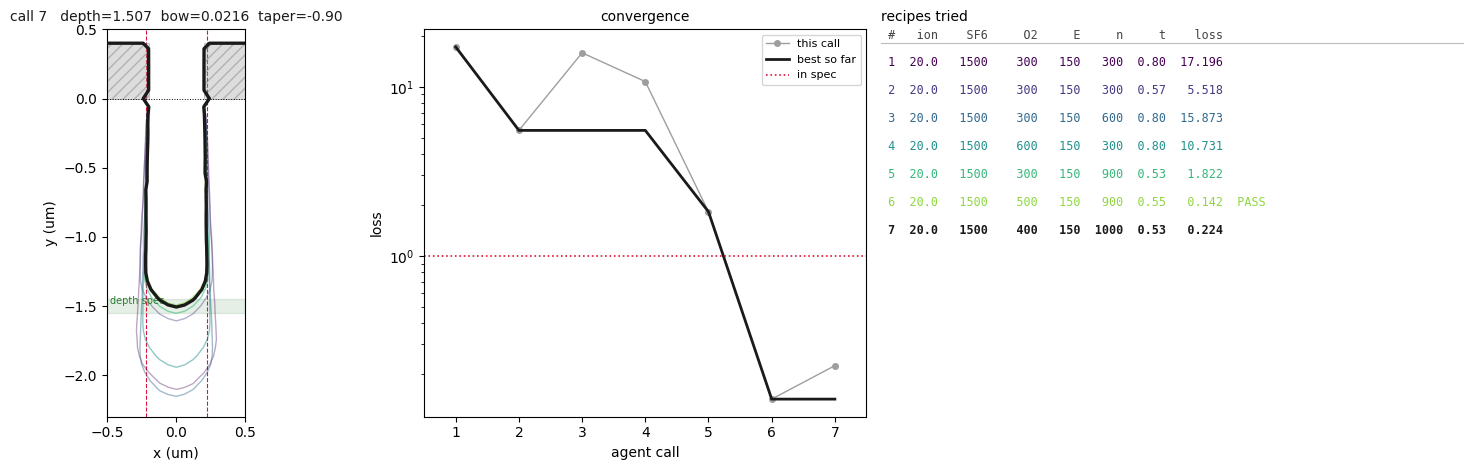

In [17]:
import textwrap

def run_agent(budget=12, pause=0.4):
    LOG.clear(); TRACE.clear(); PARAMS.clear()
    messages = [{"role": "user", "content":
                 f"Find a passing recipe. You may call the tool at most {budget} times. "
                 f"Start with a baseline you can reason from."}]
    calls = 0
    while calls < budget:
        resp = client.messages.create(model=MODEL, max_tokens=1500, system=SYSTEM,
                                      tools=[ETCH_TOOL], messages=messages)
        messages.append({"role": "assistant", "content": resp.content})

        if resp.stop_reason != "tool_use":
            final = "".join(b.text for b in resp.content if b.type == "text")
            LOG.append("\n=== AGENT STOPPED ===\n" + textwrap.fill(final, 96))
            if TRACE:
                live_view(pause=0)
            else:
                print("\n".join(LOG))
            break

        # the agent's stated hypothesis, logged before its consequence
        for block in resp.content:
            if block.type == "text" and block.text.strip():
                LOG.append("\n[hypothesis] " + textwrap.fill(
                    block.text.strip(), 96, subsequent_indent="             "))

        results = []
        for block in resp.content:
            if block.type != "tool_use":
                continue
            calls += 1
            prof, out = run_recipe(tag="agent", **block.input)

            knobs = "  ".join(f"{k}={v:g}" for k, v in sorted(block.input.items()))
            LOG.append(f"[call {calls:2d}]  {knobs}")
            LOG.append(f"           -> depth={out['depth']:.3f}  bow={out['bow']:.4f}  "
                       f"taper={out['taper_deg']:+.2f}  loss={out['loss']:.3f}  "
                       f"{'PASS' if out['passed'] else 'fail'}")

            TRACE.append((prof, out))
            PARAMS.append(dict(block.input))
            live_view(pause=pause)          # <-- redraw as the search happens

            results.append({"type": "tool_result", "tool_use_id": block.id,
                            "content": json.dumps(out)})
        messages.append({"role": "user", "content": results})

    return [h for h in HISTORY if h["tag"] == "agent"]

agent_runs = run_agent(budget=12)

## 4. The honest baseline

An agent that beats nothing has proven nothing. Same simulator, same budget, random search
over the same bounds (log-uniform on the flux knobs, which is what you'd do by hand).

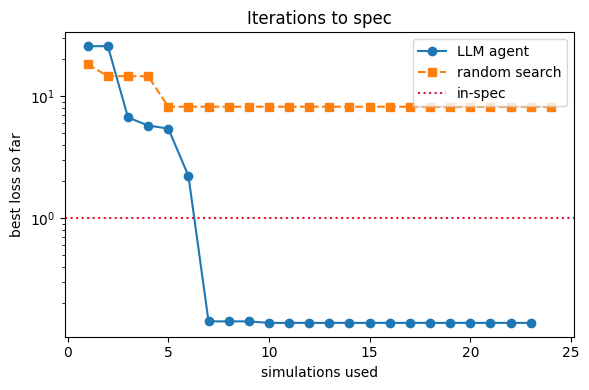

agent   best loss = 0.138   first pass at call 10
random  best loss = 8.182   first pass at call never


In [18]:
rng = np.random.default_rng(0)

def random_search(budget=12):
    for _ in range(budget):
        kw = {}
        for k, (lo, hi) in BOUNDS.items():
            if k in ("etchant_flux", "oxygen_flux", "ion_exponent"):
                kw[k] = float(np.exp(rng.uniform(np.log(lo), np.log(hi))))
            else:
                kw[k] = float(rng.uniform(lo, hi))
        run_recipe(tag="random", **kw)
    return [h for h in HISTORY if h["tag"] == "random"]

random_runs = random_search(12)

def best_curve(runs):
    return np.minimum.accumulate([r["loss"] for r in runs])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(agent_runs)+1),  best_curve(agent_runs),  "o-", label="LLM agent")
ax.plot(range(1, len(random_runs)+1), best_curve(random_runs), "s--", label="random search")
ax.axhline(1.0, color="crimson", ls=":", label="in-spec")
ax.set_xlabel("simulations used"); ax.set_ylabel("best loss so far")
ax.set_yscale("log"); ax.legend(); ax.set_title("Iterations to spec")
plt.tight_layout(); plt.show()

for name, runs in [("agent", agent_runs), ("random", random_runs)]:
    hits = [i+1 for i, r in enumerate(runs) if r["passed"]]
    print(f"{name:7s} best loss = {min(r['loss'] for r in runs):.3f}   "
          f"first pass at call {hits[0] if hits else 'never'}")

{
  "tag": "agent",
  "params": {
    "ion_flux": 20.0,
    "etchant_flux": 1500.0,
    "oxygen_flux": 550.0,
    "mean_ion_energy": 150.0,
    "ion_exponent": 1000.0,
    "duration": 0.57
  },
  "depth": 1.5069,
  "taper_deg": -0.812,
  "bow": 0.0187,
  "cd_top": 0.3964,
  "loss": 0.138,
  "depth_err": 0.14,
  "bow_pen": 0.0,
  "taper_pen": 0.0,
  "passed": true
}


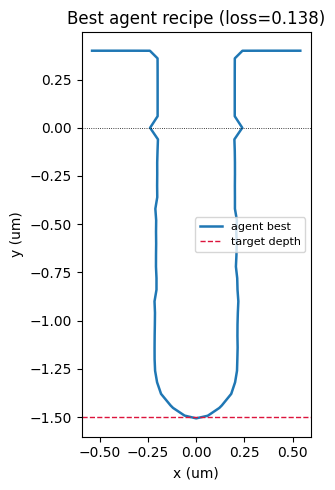

In [19]:
best = min(agent_runs, key=lambda r: r["loss"])
print(json.dumps(best, indent=2))
prof, _ = run_recipe(tag="final", **best["params"])
plot_profiles([("agent best", prof)], f"Best agent recipe (loss={best['loss']})")

## 5. Exercises

1. **Tool design.** Strip the causal hints out of the tool description (delete "higher = more
   directional", "negative means bowed"). Re-run. How many extra simulations does the agent
   need? This is the lab's real lesson: agent performance is mostly *interface* design.
2. **Stronger baseline.** Replace random search with Bayesian optimization
   (`scikit-optimize` or a simple GP). Does the LLM still win at n=12? At n=50? Where's the
   crossover, and why?
3. **Add a competing spec.** Require `cd_top <= 0.41` (no mask undercut) *and* depth ≥ 2.0 µm.
   Is it satisfiable? Can the agent tell you it isn't, or does it hallucinate a solution?
   Infeasibility detection is a genuine failure mode of these systems.
4. **Multi-agent.** Split into a *proposer* (suggests recipes) and a *critic* (reviews the
   metrology and challenges the hypothesis), as in AgenticTCAD. Measure whether the extra
   tokens buy anything.
5. **3D.** Switch to `vps.setDimension(3)` with `vps.MakeHole`. Cost per simulation jumps by
   ~50×. Does the agent's sample efficiency justify the wall-clock, versus a surrogate model
   trained on 2D runs?
6. **Reliability.** Run the same agent 5 times with `temperature=1`. Report the spread in
   iterations-to-spec. Would you put this in a fab?

## 6. Swapping in an open-source model

To run the identical loop against **SemiKong** (Llama-3.1-based, semiconductor-tuned,
Apache 2.0) instead of a frontier model, serve it locally and point an OpenAI-compatible
client at it:

```bash
pip install vllm
vllm serve pentagoniac/SemiKong-8B --port 8000
```

```python
from openai import OpenAI
client = OpenAI(base_url="http://localhost:8000/v1", api_key="none")
# convert ETCH_TOOL to OpenAI function-calling format and reuse run_agent()
```

Interesting class comparison: a domain-tuned 8B model against a general frontier model on the
*same* tool loop. Domain knowledge in the weights vs. reasoning over tool feedback — which
matters more here?